# Import Modules and Functions

In [1]:
import sys, os

mod_dir = os.path.abspath('/Users/rangulo/projects/EtaCar_LEs/python')
sys.path.append(mod_dir)

from LC_utility import *

In [2]:
%load_ext autoreload
%autoreload 2

# Read in Data

In [3]:
## Original difference images
table_a57i = pd.read_csv('LC_tables/good2/LCref_a57_i.csv')
table_a57g = pd.read_csv('LC_tables/good2/LCref_a57_g.csv')
table_a57r = pd.read_csv('LC_tables/good2/LCref_a57_r.csv')
table_a57z = pd.read_csv('LC_tables/good2/LCref_a57_z.csv')

table_a54i = pd.read_csv('LC_tables/good2/LCref_a54_i.csv')
table_a54r = pd.read_csv('LC_tables/good2/LCref_a54_r.csv')
table_a54g = pd.read_csv('LC_tables/good2/LCref_a54_g.csv')
table_a54z = pd.read_csv('LC_tables/good2/LCref_a54_z.csv')

## segment 1
lc_df1i = readin_LCdf('LC_tables/good2/LCtable1_i.csv')
lc_df1g = readin_LCdf('LC_tables/good2/LCtable1_g.csv')
lc_df1r = readin_LCdf('LC_tables/good2/LCtable1_r.csv')
lc_df1z = readin_LCdf('LC_tables/good2/LCtable1_z.csv')


## segment 2
lc_df2i = readin_LCdf('LC_tables/good2/LCtable2_i.csv')
lc_df2g = readin_LCdf('LC_tables/good2/LCtable2_g.csv')
lc_df2r = readin_LCdf('LC_tables/good2/LCtable2_r.csv')
lc_df2z = readin_LCdf('LC_tables/good2/LCtable2_z.csv')

## segment 3
lc_df3i = readin_LCdf('LC_tables/good2/LCtable3_i.csv')
lc_df3g = readin_LCdf('LC_tables/good2/LCtable3_g.csv')
lc_df3r = readin_LCdf('LC_tables/good2/LCtable3_r.csv')
lc_df3z = readin_LCdf('LC_tables/good2/LCtable3_z.csv')

## segment 4
lc_df4i = readin_LCdf('LC_tables/good2/LCtable4_i.csv')
lc_df4g = readin_LCdf('LC_tables/good2/LCtable4_g.csv')
lc_df4r = readin_LCdf('LC_tables/good2/LCtable4_r.csv')
lc_df4z = readin_LCdf('LC_tables/good2/LCtable4_z.csv')

In [4]:
## Band subtracted diffs
btable_a54i = pd.read_csv('LC_tables/bandcorr/LCref_a54_i.csv')
btable_a54r = pd.read_csv('LC_tables/bandcorr/LCref_a54_r.csv')
btable_a54g = pd.read_csv('LC_tables/bandcorr/LCref_a54_g.csv')
btable_a54z = pd.read_csv('LC_tables/bandcorr/LCref_a54_z.csv')

## segment 2
blc_df2i = readin_LCdf('LC_tables/bandcorr/LCtable2_i.csv')
blc_df2g = readin_LCdf('LC_tables/bandcorr/LCtable2_g.csv')
blc_df2r = readin_LCdf('LC_tables/bandcorr/LCtable2_r.csv')
blc_df2z = readin_LCdf('LC_tables/bandcorr/LCtable2_z.csv')

## segment 3
blc_df3i = readin_LCdf('LC_tables/bandcorr/LCtable3_i.csv')
blc_df3g = readin_LCdf('LC_tables/bandcorr/LCtable3_g.csv')
blc_df3r = readin_LCdf('LC_tables/bandcorr/LCtable3_r.csv')
blc_df3z = readin_LCdf('LC_tables/bandcorr/LCtable3_z.csv')

## segment 4
blc_df4i = readin_LCdf('LC_tables/bandcorr/LCtable4_i.csv')
blc_df4g = readin_LCdf('LC_tables/bandcorr/LCtable4_g.csv')
blc_df4r = readin_LCdf('LC_tables/bandcorr/LCtable4_r.csv')
blc_df4z = readin_LCdf('LC_tables/bandcorr/LCtable4_z.csv')

In [5]:
### Some images need to be excluded due to quality
bad_expnums_a54g = pd.read_csv('txt_files/a54g_badims.csv')['a54'].values
bad_expnums_a54r = pd.read_csv('txt_files/a54r_badims.csv')['a54'].values
bad_expnums_a54i = pd.read_csv('txt_files/a54i_badims.csv')['a54'].values
bad_expnums_a54z = pd.read_csv('txt_files/a54z_badims.csv')['a54'].values

bad_expnums_a57g = pd.read_csv('txt_files/a57g_badims.csv')['a57'].values
bad_expnums_a57r = pd.read_csv('txt_files/a57r_badims.csv')['a57'].values
bad_expnums_a57i = pd.read_csv('txt_files/a57i_badims.csv')['a57'].values
bad_expnums_a57z = pd.read_csv('txt_files/a57z_badims.csv')['a57'].values


### Some images have bad bands -- we have versions with the bands subtracted (manually)
badb_expnums_a54g = pd.read_csv('txt_files/a54g_badbs.csv')['a54'].values
badb_expnums_a54r = pd.read_csv('txt_files/a54r_badbs.csv')['a54'].values
badb_expnums_a54i = pd.read_csv('txt_files/a54i_badbs.csv')['a54'].values
badb_expnums_a54z = pd.read_csv('txt_files/a54z_badbs.csv')['a54'].values

In [6]:
### Swap row entries of bad bands images
for i in badb_expnums_a54g:
    ind2 = lc_df2g.ix_equal('im_expnum',i)
    ind3 = lc_df3g.ix_equal('im_expnum',i)
    ind4 = lc_df4g.ix_equal('im_expnum',i)

    bind2 = blc_df2g.ix_equal('im_expnum',i)
    bind3 = blc_df3g.ix_equal('im_expnum',i)
    bind4 = blc_df4g.ix_equal('im_expnum',i)

    lc_df2g.t.loc[ind2,'muJyas2'] = blc_df2g.t.loc[bind2,'muJyas2']
    lc_df2g.t.loc[ind2,'muJyas2_err'] = blc_df2g.t.loc[bind2,'muJyas2_err']

    lc_df3g.t.loc[ind3,'muJyas2'] = blc_df3g.t.loc[bind3,'muJyas2']
    lc_df3g.t.loc[ind3,'muJyas2_err'] = blc_df3g.t.loc[bind3,'muJyas2_err']

    lc_df4g.t.loc[ind4,'muJyas2'] = blc_df4g.t.loc[bind4,'muJyas2']
    lc_df4g.t.loc[ind4,'muJyas2_err'] = blc_df4g.t.loc[bind4,'muJyas2_err']


for i in badb_expnums_a54r:
    ind2 = lc_df2r.ix_equal('im_expnum',i)
    ind3 = lc_df3r.ix_equal('im_expnum',i)
    ind4 = lc_df4r.ix_equal('im_expnum',i)

    bind2 = blc_df2r.ix_equal('im_expnum',i)
    bind3 = blc_df3r.ix_equal('im_expnum',i)
    bind4 = blc_df4r.ix_equal('im_expnum',i)

    lc_df2r.t.loc[ind2,'muJyas2'] = blc_df2r.t.loc[bind2,'muJyas2']
    lc_df2r.t.loc[ind2,'muJyas2_err'] = blc_df2r.t.loc[bind2,'muJyas2_err']

    lc_df3r.t.loc[ind3,'muJyas2'] = blc_df3r.t.loc[bind3,'muJyas2']
    lc_df3r.t.loc[ind3,'muJyas2_err'] = blc_df3r.t.loc[bind3,'muJyas2_err']

    lc_df4r.t.loc[ind4,'muJyas2'] = blc_df4r.t.loc[bind4,'muJyas2']
    lc_df4r.t.loc[ind4,'muJyas2_err'] = blc_df4r.t.loc[bind4,'muJyas2_err']


for i in badb_expnums_a54i:
    ind2 = lc_df2i.ix_equal('im_expnum',i)
    ind3 = lc_df3i.ix_equal('im_expnum',i)
    ind4 = lc_df4i.ix_equal('im_expnum',i)

    bind2 = blc_df2i.ix_equal('im_expnum',i)
    bind3 = blc_df3i.ix_equal('im_expnum',i)
    bind4 = blc_df4i.ix_equal('im_expnum',i)

    lc_df2i.t.loc[ind2,'muJyas2'] = blc_df2i.t.loc[bind2,'muJyas2']
    lc_df2i.t.loc[ind2,'muJyas2_err'] = blc_df2i.t.loc[bind2,'muJyas2_err']

    lc_df3i.t.loc[ind3,'muJyas2'] = blc_df3i.t.loc[bind3,'muJyas2']
    lc_df3i.t.loc[ind3,'muJyas2_err'] = blc_df3i.t.loc[bind3,'muJyas2_err']

    lc_df4i.t.loc[ind4,'muJyas2'] = blc_df4i.t.loc[bind4,'muJyas2']
    lc_df4i.t.loc[ind4,'muJyas2_err'] = blc_df4i.t.loc[bind4,'muJyas2_err']


for i in badb_expnums_a54z:
    ind2 = lc_df2z.ix_equal('im_expnum',i)
    ind3 = lc_df3z.ix_equal('im_expnum',i)
    ind4 = lc_df4z.ix_equal('im_expnum',i)
    
    bind2 = blc_df2z.ix_equal('im_expnum',i)
    bind3 = blc_df3z.ix_equal('im_expnum',i)
    bind4 = blc_df4z.ix_equal('im_expnum',i)
    
    lc_df2z.t.loc[ind2,'muJyas2'] = blc_df2z.t.loc[bind2,'muJyas2']
    lc_df2z.t.loc[ind2,'muJyas2_err'] = blc_df2z.t.loc[bind2,'muJyas2_err']
    
    lc_df3z.t.loc[ind3,'muJyas2'] = blc_df3z.t.loc[bind3,'muJyas2']
    lc_df3z.t.loc[ind3,'muJyas2_err'] = blc_df3z.t.loc[bind3,'muJyas2_err']
    
    lc_df4z.t.loc[ind4,'muJyas2'] = blc_df4z.t.loc[bind4,'muJyas2']
    lc_df4z.t.loc[ind4,'muJyas2_err'] = blc_df4z.t.loc[bind4,'muJyas2_err']

In [7]:
diffsa54 = pdastroclass()
diffsa54.load('txt_files/ec0915a54_diffs.txt')

diffsa57 = pdastroclass()
diffsa57.load('txt_files/ec0915a57_diffs.txt')

diffsa54.t['im_expnum'] = [int(re.search('\.(\d+)_ooi_',os.path.basename(diff_nm)).groups()[0]) for diff_nm in diffsa54.t['FITSNAME']]
diffsa57.t['im_expnum'] = [int(re.search('\.(\d+)_ooi_',os.path.basename(diff_nm)).groups()[0]) for diff_nm in diffsa57.t['FITSNAME']]

phot_a54_dict = {'g':3559443, 'r':3559444, 'i':3559445, 'z':3559446}
phot_a57_dict = {'g':3756051, 'r':3756052, 'i':3756053, 'z':3756054}

In [8]:
### Read in iteration 1 LC model
LCmodel1g = pd.read_csv('LC_tables/good2/models/gLC_m1.csv')
LCmodel1r = pd.read_csv('LC_tables/good2/models/rLC_m1.csv')
LCmodel1i = pd.read_csv('LC_tables/good2/models/iLC_m1.csv')
LCmodel1z = pd.read_csv('LC_tables/good2/models/zLC_m1.csv')

# Combine LCs

### Fitting Process for Each Segment

In [9]:
### Define uncertainty/error cut on flux error -- exclude outliers from fitting
### The working indices for fitting process -- run before the rest
### Also find peak location to fit light curves together
flag_inds(lc_df1g, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a57g, bin_size='gauss', peak_range='full', diffstats=diffsa57)
flag_inds(lc_df1r, f_lm=15.0, ferr_lm=1.0, bad_expnums=bad_expnums_a57r, bin_size='gauss', peak_range='full', diffstats=diffsa57)
flag_inds(lc_df1i, f_lm=20.0, ferr_lm=1.0, bad_expnums=bad_expnums_a57i, bin_size='gauss', peak_range='full', diffstats=diffsa57)
flag_inds(lc_df1z, f_lm=15.0, ferr_lm=1.0, bad_expnums=bad_expnums_a57z, bin_size='gauss', peak_range='full', diffstats=diffsa57)

flag_inds(lc_df2g, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54g, bin_size='gauss', peak_range='full', diffstats=diffsa54)
flag_inds(lc_df2r, f_lm=10.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54r, bin_size='gauss', peak_range='full', diffstats=diffsa54)
flag_inds(lc_df2i, f_lm=12.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54i, bin_size='gauss', peak_range='full', diffstats=diffsa54)
flag_inds(lc_df2z, f_lm=12.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54z, bin_size='gauss', peak_range='full', diffstats=diffsa54)

flag_inds(lc_df3g, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54g, bin_size='gauss', peak_range=[57300,58000], diffstats=diffsa54)
flag_inds(lc_df3r, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54r, bin_size='gauss', peak_range=[57300,58000], diffstats=diffsa54)
flag_inds(lc_df3i, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54i, bin_size='gauss', peak_range=[57300,58000], diffstats=diffsa54)
flag_inds(lc_df3z, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54z, bin_size='gauss', peak_range=[57300,58000], diffstats=diffsa54)

flag_inds(lc_df4g, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54g, bin_size='gauss', peak_range=None, diffstats=diffsa54)
flag_inds(lc_df4r, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54r, bin_size='gauss', peak_range=None, diffstats=diffsa54)
flag_inds(lc_df4i, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54i, bin_size='gauss', peak_range=None, diffstats=diffsa54)
flag_inds(lc_df4z, f_lm=5.0, ferr_lm=1.0, bad_expnums=bad_expnums_a54z, bin_size='gauss', peak_range=None, diffstats=diffsa54)

'Updated LC dataframe -- flagged working indices'

In [10]:
### Fit LCs to a template
### 2nd iteration --> template is the model LC

## segment 1
fit_parms1i = fit_LCs(lc_df1i, LCmodel=LCmodel1i)
fit_parms1g = fit_LCs(lc_df1g, LCmodel=LCmodel1g, tshift_ls=fit_parms1i[1])
fit_parms1r = fit_LCs(lc_df1r, LCmodel=LCmodel1r, tshift_ls=fit_parms1i[1])
fit_parms1z = fit_LCs(lc_df1z, LCmodel=LCmodel1z, tshift_ls=fit_parms1i[1])

## segment 2
fit_parms2i = fit_LCs(lc_df2i, LCmodel=LCmodel1i)
fit_parms2g = fit_LCs(lc_df2g, LCmodel=LCmodel1g, tshift_ls=fit_parms2i[1])
fit_parms2r = fit_LCs(lc_df2r, LCmodel=LCmodel1r, tshift_ls=fit_parms2i[1])
fit_parms2z = fit_LCs(lc_df2z, LCmodel=LCmodel1z, tshift_ls=fit_parms2i[1])

## segment 3 -- find proper peak in model
m_tpeaki = find_t_peak(LCmodel1i['mjd'].values,LCmodel1i['muJyas2'].values,LCmodel1i['muJyas2_err'].values, metric=None, t_range=[59000,59700])
ginds_3i = lc_df3i.t['g_ixs_flag'].eq(True)
tshifts_3i = [m_tpeaki - i for i in np.unique(lc_df3i.t.loc[ginds_3i,'peak_loc'])]
fit_parms3i = fit_LCs(lc_df3i, LCmodel=LCmodel1i, tshift_ls=tshifts_3i)

fit_parms3g = fit_LCs(lc_df3g, LCmodel=LCmodel1g, tshift_ls=fit_parms3i[1])
fit_parms3r = fit_LCs(lc_df3r, LCmodel=LCmodel1r, tshift_ls=fit_parms3i[1])
fit_parms3z = fit_LCs(lc_df3z, LCmodel=LCmodel1z, tshift_ls=fit_parms3i[1])

## segment 4
    # no tshift as the tail end seems aligned -- also no specific feature to pinpoint
    # just fit to end of model
fit_parms4i = fit_LCs(lc_df4i, LCmodel=LCmodel1i, peak_range=None)
fit_parms4g = fit_LCs(lc_df4g, LCmodel=LCmodel1g, tshift_ls=fit_parms4i[1])
fit_parms4r = fit_LCs(lc_df4r, LCmodel=LCmodel1r, tshift_ls=fit_parms4i[1])
fit_parms4z = fit_LCs(lc_df4z, LCmodel=LCmodel1z, tshift_ls=fit_parms4i[1])

In [11]:
### Create data frame of aligned and combined LCs

# ## segment 1
comb1g = get_combLCs(lc_df1g, fit_parms1g, LCmodel=LCmodel1g)
comb1r = get_combLCs(lc_df1r, fit_parms1r, LCmodel=LCmodel1r)
comb1i = get_combLCs(lc_df1i, fit_parms1i, LCmodel=LCmodel1i)
comb1z = get_combLCs(lc_df1z, fit_parms1z, LCmodel=LCmodel1z)

# ## segment 2
comb2g = get_combLCs(lc_df2g, fit_parms2g, LCmodel=LCmodel1g)
comb2r = get_combLCs(lc_df2r, fit_parms2r, LCmodel=LCmodel1r)
comb2i = get_combLCs(lc_df2i, fit_parms2i, LCmodel=LCmodel1i)
comb2z = get_combLCs(lc_df2z, fit_parms2z, LCmodel=LCmodel1z)

# ## segment 3
comb3g = get_combLCs(lc_df3g, fit_parms3g, LCmodel=LCmodel1g)
comb3r = get_combLCs(lc_df3r, fit_parms3r, LCmodel=LCmodel1r)
comb3i = get_combLCs(lc_df3i, fit_parms3i, LCmodel=LCmodel1i)
comb3z = get_combLCs(lc_df3z, fit_parms3z, LCmodel=LCmodel1z)

# ## segment 4
comb4g = get_combLCs(lc_df4g, fit_parms4g, LCmodel=LCmodel1g)
comb4r = get_combLCs(lc_df4r, fit_parms4r, LCmodel=LCmodel1r)
comb4i = get_combLCs(lc_df4i, fit_parms4i, LCmodel=LCmodel1i)
comb4z = get_combLCs(lc_df4z, fit_parms4z, LCmodel=LCmodel1z)

### See/Check Fitting Process

In [12]:
### See individual LCs

## 4 segments (labelled 1-4)

# plot_lcs(lc_df3i, plot_orig=False)
# plot_lcs(lc_df1, plt_xl=60400)

In [13]:
### Check how peaks are found

# ch_df = lc_df1i
# lc_ids = np.unique(ch_df.t['ID'])
# for i in lc_ids: 
#     print(i)
#     check_inds = np.where(ch_df.t['ID'].eq(i) & ch_df.t['g_ixs_flag'].eq(True))[0]
#     ch_t, ch_mu, ch_std = get_LCfit(ch_df,indices=check_inds, metric=1e4)

#     plt.scatter(ch_df.t.loc[check_inds,'mjd'], ch_df.t.loc[check_inds,'muJyas2'])
#     plt.scatter(ch_t,ch_mu)

#     # tpeak = find_t_peak(ch_t,ch_mu,ch_std, metric=None, t_range=[57300,58000])
#     # print(tpeak)
#     # plt.axvline(tpeak)
    
#     plt.show()

In [14]:
### See Fitting Process

# df = lc_df2i
# fit_ps = fit_parms2i
# lcmodel_ps = LCmodel1i

# plot_LCfits(df,fit_ps, LCmodel=lcmodel_ps)

In [15]:
### See comb LCs

# df = lc_df3z
# fit_ps = fit_parms3z
# t_ID = templ_ID3

# for i in fit_ps[0]:
#     df_inds = get_LCinds(df, lc_ID=i)
#     plt.errorbar(df.t.loc[df_inds,'new_mjd'], df.t.loc[df_inds,'new_muJyas2'], yerr=df.t.loc[df_inds,'new_muJyas2_err'], fmt='.-', ecolor='black')

In [16]:
### See combined LC
# test_range = [0,-1]
# vals_g = [comb2g, co_t2g[test_range[0]:test_range[1]], co_mu2g[test_range[0]:test_range[1]], co_std2g[test_range[0]:test_range[1]]]
# vals_r = [comb2r, co_t2r[test_range[0]:test_range[1]], co_mu2r[test_range[0]:test_range[1]], co_std2r[test_range[0]:test_range[1]]]
# vals_i = [comb2i, co_t2i[test_range[0]:test_range[1]], co_mu2i[test_range[0]:test_range[1]], co_std2i[test_range[0]:test_range[1]]]
# vals_z = [comb2z, co_t2z[test_range[0]:test_range[1]], co_mu2z[test_range[0]:test_range[1]], co_std2z[test_range[0]:test_range[1]]]


# plt.errorbar(vals_g[0].t['mjd'], vals_g[0].t['muJyas2'], fmt='.', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(vals_g[1], vals_g[2], fmt='--.', ecolor='black', color='orange') #,yerr=vals_g[3]
# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# # plt.ylim(-1,3)
# plt.show()

# plt.errorbar(vals_r[0].t['mjd'], vals_r[0].t['muJyas2'], fmt='.', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(vals_r[1], vals_r[2], fmt='--.', ecolor='black', color='orange') #,yerr=vals_r[3]
# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# # plt.ylim(-1,3)
# plt.show()

# plt.errorbar(vals_i[0].t['mjd'], vals_i[0].t['muJyas2'], fmt='.', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(vals_i[1], vals_i[2], fmt='--.', ecolor='black', color='orange') #,yerr=vals_i[3]
# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# # plt.ylim(-1,3)
# plt.show()

# plt.errorbar(vals_z[0].t['mjd'], vals_z[0].t['muJyas2'], fmt='.', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(vals_z[1], vals_z[2], fmt='--.', ecolor='black', color='orange') #,yerr=vals_z[3]
# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# # plt.ylim(-1,3)
# plt.show()

# Model LC

### Combine Segments

In [17]:
### Combine Segments
    ## Model data already connected in iteration 2
    ## Combine LC data
## g
tls_mg = np.concatenate([comb1g.t['mjd'].values, comb2g.t['mjd'].values, comb3g.t['mjd'].values, comb4g.t['mjd'].values])
fls_mg = np.concatenate([comb1g.t['muJyas2'].values, comb2g.t['muJyas2'].values, comb3g.t['muJyas2'].values, comb4g.t['muJyas2'].values])
ferrls_mg = np.concatenate([comb1g.t['muJyas2_err'].values, comb2g.t['muJyas2_err'].values, comb3g.t['muJyas2_err'].values, comb4g.t['muJyas2_err'].values])
ord_inds_mg = tls_mg.argsort()
tls_mg = tls_mg[ord_inds_mg]
fls_mg = fls_mg[ord_inds_mg]
ferrls_mg = ferrls_mg[ord_inds_mg]
comb_m_datag = {'mjd': tls_mg, 'muJyas2': fls_mg, 'muJyas2_err': ferrls_mg}
comb_mg = pdastrostatsclass()
comb_mg.t = comb_mg.t.assign(**comb_m_datag)
## r
tls_mr = np.concatenate([comb1r.t['mjd'].values, comb2r.t['mjd'].values, comb3r.t['mjd'].values, comb4r.t['mjd'].values])
fls_mr = np.concatenate([comb1r.t['muJyas2'].values, comb2r.t['muJyas2'].values, comb3r.t['muJyas2'].values, comb4r.t['muJyas2'].values])
ferrls_mr = np.concatenate([comb1r.t['muJyas2_err'].values, comb2r.t['muJyas2_err'].values, comb3r.t['muJyas2_err'].values, comb4r.t['muJyas2_err'].values])
ord_inds_mr = tls_mr.argsort()
tls_mr = tls_mr[ord_inds_mr]
fls_mr = fls_mr[ord_inds_mr]
ferrls_mr = ferrls_mr[ord_inds_mr]
comb_m_datar = {'mjd': tls_mr, 'muJyas2': fls_mr, 'muJyas2_err': ferrls_mr}
comb_mr = pdastrostatsclass()
comb_mr.t = comb_mr.t.assign(**comb_m_datar)
## i
tls_mi = np.concatenate([comb1i.t['mjd'].values, comb2i.t['mjd'].values, comb3i.t['mjd'].values, comb4i.t['mjd'].values])
fls_mi = np.concatenate([comb1i.t['muJyas2'].values, comb2i.t['muJyas2'].values, comb3i.t['muJyas2'].values, comb4i.t['muJyas2'].values])
ferrls_mi = np.concatenate([comb1i.t['muJyas2_err'].values, comb2i.t['muJyas2_err'].values, comb3i.t['muJyas2_err'].values, comb4i.t['muJyas2_err'].values])
ord_inds_mi = tls_mi.argsort()
tls_mi = tls_mi[ord_inds_mi]
fls_mi = fls_mi[ord_inds_mi]
ferrls_mi = ferrls_mi[ord_inds_mi]
comb_m_datai = {'mjd': tls_mi, 'muJyas2': fls_mi, 'muJyas2_err': ferrls_mi}
comb_mi = pdastrostatsclass()
comb_mi.t = comb_mi.t.assign(**comb_m_datai)
## z
tls_mz = np.concatenate([comb1z.t['mjd'].values, comb2z.t['mjd'].values, comb3z.t['mjd'].values, comb4z.t['mjd'].values])
fls_mz = np.concatenate([comb1z.t['muJyas2'].values, comb2z.t['muJyas2'].values, comb3z.t['muJyas2'].values, comb4z.t['muJyas2'].values])
ferrls_mz = np.concatenate([comb1z.t['muJyas2_err'].values, comb2z.t['muJyas2_err'].values, comb3z.t['muJyas2_err'].values, comb4z.t['muJyas2_err'].values])
ord_inds_mz = tls_mz.argsort()
tls_mz = tls_mz[ord_inds_mz]
fls_mz = fls_mz[ord_inds_mz]
ferrls_mz = ferrls_mz[ord_inds_mz]
comb_m_dataz = {'mjd': tls_mz, 'muJyas2': fls_mz, 'muJyas2_err': ferrls_mz}
comb_mz = pdastrostatsclass()
comb_mz.t = comb_mz.t.assign(**comb_m_dataz)

In [18]:
### Create the model (LC_0)
## i
m_ti, m_mui, m_stdi = get_LCfit(comb_mi, metric=5e4)
main_peak = m_ti[np.where(m_mui==max(m_mui))[0][0]]
phase_mi = m_ti - main_peak
lc_modeli = {'mjd':m_ti, 'muJyas2':m_mui, 'muJyas2_err':m_stdi, 'phase':phase_mi}
lc_model_di = pd.DataFrame(lc_modeli)
comb_mi.t['phase'] = comb_mi.t['mjd'] - main_peak

## g
m_tg, m_mug, m_stdg = get_LCfit(comb_mg, metric=5e4)
phase_mg = m_tg - main_peak
lc_modelg = {'mjd':m_tg, 'muJyas2':m_mug, 'muJyas2_err':m_stdg, 'phase':phase_mg}
lc_model_dg = pd.DataFrame(lc_modelg)
comb_mg.t['phase'] = comb_mg.t['mjd'] - main_peak
## r
m_tr, m_mur, m_stdr = get_LCfit(comb_mr, metric=5e4)
phase_mr = m_tr - main_peak
lc_modelr = {'mjd':m_tr, 'muJyas2':m_mur, 'muJyas2_err':m_stdr, 'phase':phase_mr}
lc_model_dr = pd.DataFrame(lc_modelr)
comb_mr.t['phase'] = comb_mr.t['mjd'] - main_peak
## z
m_tz, m_muz, m_stdz = get_LCfit(comb_mz, metric=5e4)
phase_mz = m_tz - main_peak
lc_modelz = {'mjd':m_tz, 'muJyas2':m_muz, 'muJyas2_err':m_stdz, 'phase':phase_mz}
lc_model_dz = pd.DataFrame(lc_modelz)
comb_mz.t['phase'] = comb_mz.t['mjd'] - main_peak

In [19]:
### Save tables

## i
lc_model_di.to_csv('LC_tables/good2/models/iLC_m2.csv', index=False)
comb_mi.t.to_csv('LC_tables/good2/models/iLC_data2.csv', index=False)

## g
lc_model_dg.to_csv('LC_tables/good2/models/gLC_m2.csv', index=False)
comb_mg.t.to_csv('LC_tables/good2/models/gLC_data2.csv', index=False)

## r
lc_model_dr.to_csv('LC_tables/good2/models/rLC_m2.csv', index=False)
comb_mr.t.to_csv('LC_tables/good2/models/rLC_data2.csv', index=False)

## z
lc_model_dz.to_csv('LC_tables/good2/models/zLC_m2.csv', index=False)
comb_mz.t.to_csv('LC_tables/good2/models/zLC_data2.csv', index=False)

### See Model Fitting

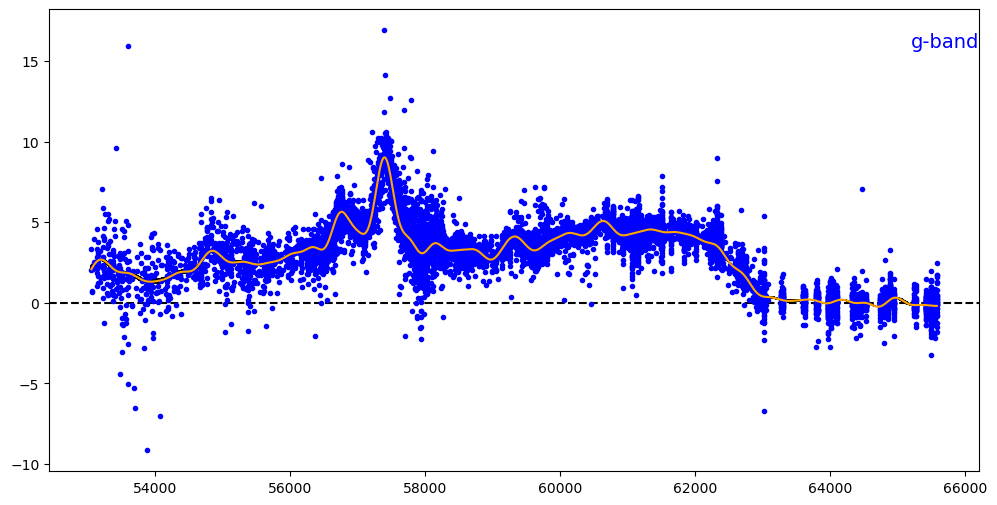

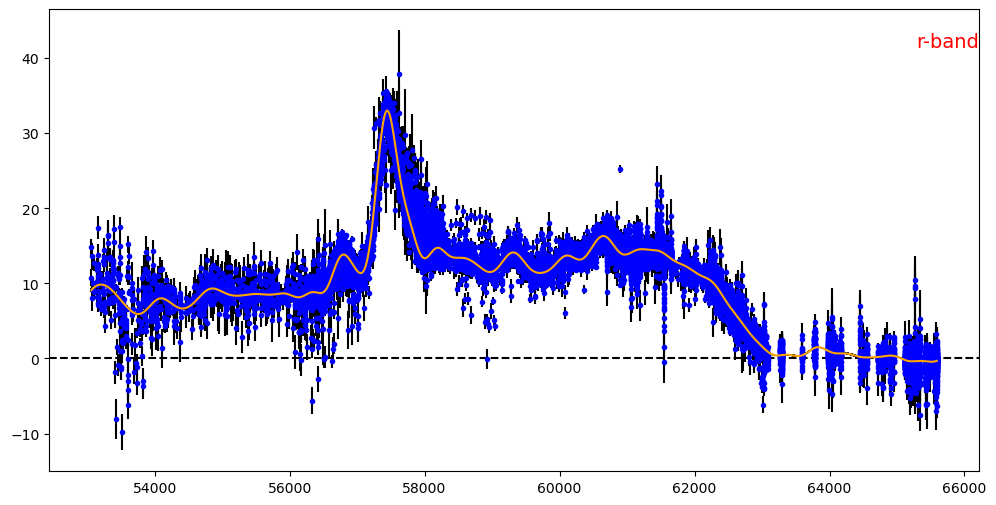

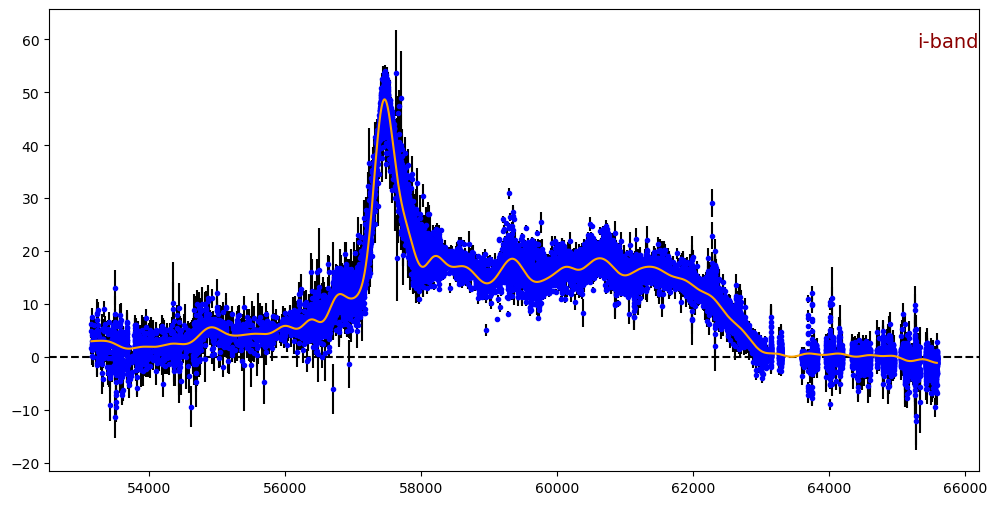

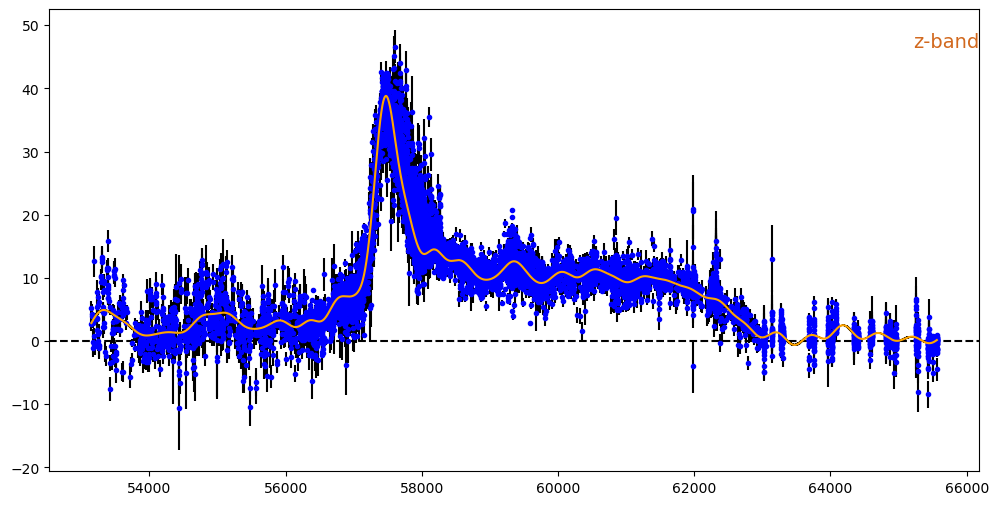

In [20]:
## Plot Model
plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_mg.t['mjd'], comb_mg.t['muJyas2'], fmt='.', ecolor='black', color='blue')#, yerr=comb_mg.t['muJyas2_err'])
plt.errorbar(m_tg, m_mug, fmt='-', ecolor='black', color='orange', yerr=m_stdg)
plt.axhline(y=0, linestyle='--', color='black')
plt.title('g-band', loc='right', y=0.9, color='blue', fontsize=14.)
plt.show()

plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_mr.t['mjd'], comb_mr.t['muJyas2'], fmt='.', ecolor='black', color='blue', yerr=comb_mr.t['muJyas2_err'])
plt.errorbar(m_tr, m_mur, fmt='-', ecolor='black', color='orange', yerr=m_stdr)
plt.axhline(y=0, linestyle='--', color='black')
plt.title('r-band', loc='right', y=0.9, color='red', fontsize=14.)
plt.show()

plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_mi.t['mjd'], comb_mi.t['muJyas2'], fmt='.', ecolor='black', color='blue', yerr=comb_mi.t['muJyas2_err'])
plt.errorbar(m_ti, m_mui, fmt='-', ecolor='black', color='orange', yerr=m_stdi)
plt.axhline(y=0, linestyle='--', color='black')
plt.title('i-band', loc='right', y=0.9, color='darkred', fontsize=14.)
plt.show()

plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_mz.t['mjd'], comb_mz.t['muJyas2'], fmt='.', ecolor='black', color='blue', yerr=comb_mz.t['muJyas2_err'])
plt.errorbar(m_tz, m_muz, fmt='-', ecolor='black', color='orange', yerr=m_stdz)
plt.axhline(y=0, linestyle='--', color='black')
plt.title('z-band', loc='right', y=0.9, color='chocolate', fontsize=14.)
plt.show()

# Check Normalizations

In [21]:
gparams = [np.array(fit_parms1g[2]), np.array(fit_parms2g[2]), np.array(fit_parms3g[2]), np.array(fit_parms4g[2])]
rparams = [np.array(fit_parms1r[2]), np.array(fit_parms2r[2]), np.array(fit_parms3r[2]), np.array(fit_parms4r[2])]
iparams = [np.array(fit_parms1i[2]), np.array(fit_parms2i[2]), np.array(fit_parms3i[2]), np.array(fit_parms4i[2])]
zparams = [np.array(fit_parms1z[2]), np.array(fit_parms2z[2]), np.array(fit_parms3z[2]), np.array(fit_parms4z[2])]

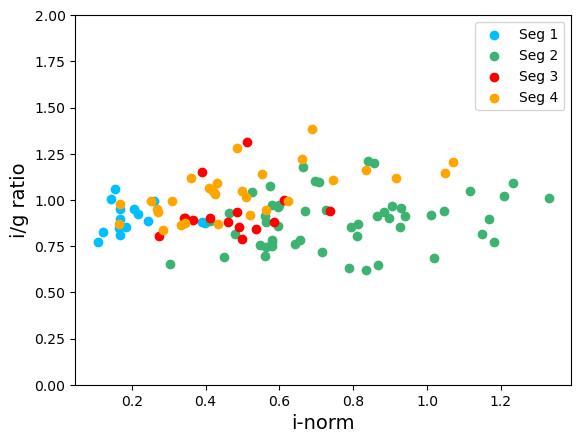

In [22]:
plt.scatter(iparams[0], iparams[0]/gparams[0], label='Seg 1', color='deepskyblue')
plt.scatter(iparams[1], iparams[1]/gparams[1], label='Seg 2', color='mediumseagreen')
plt.scatter(iparams[2], iparams[2]/gparams[2], label='Seg 3', color='red')
plt.scatter(iparams[3], iparams[3]/gparams[3], label='Seg 4', color='orange')

plt.ylim(0,2)
plt.xlabel('i-norm', fontsize=14)
plt.ylabel('i/g ratio', fontsize=14)
plt.legend()
plt.show()

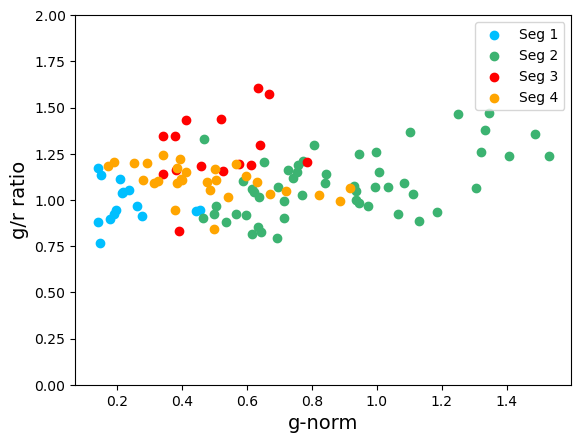

In [23]:
plt.scatter(gparams[0], gparams[0]/rparams[0], label='Seg 1', color='deepskyblue')
plt.scatter(gparams[1], gparams[1]/rparams[1], label='Seg 2', color='mediumseagreen')
plt.scatter(gparams[2], gparams[2]/rparams[2], label='Seg 3', color='red')
plt.scatter(gparams[3], gparams[3]/rparams[3], label='Seg 4', color='orange')

plt.ylim(0,2)
plt.xlabel('g-norm', fontsize=14)
plt.ylabel('g/r ratio', fontsize=14)
plt.legend()
plt.show()

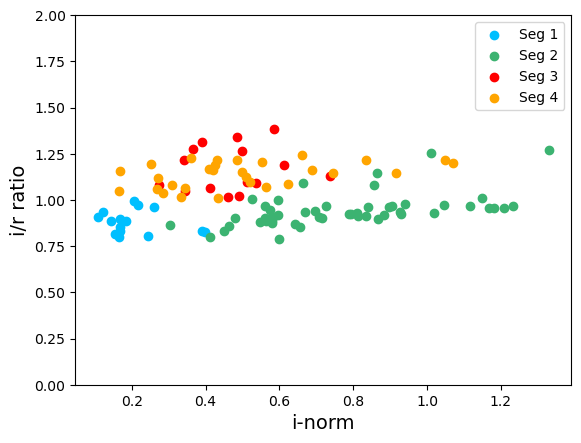

In [24]:
plt.scatter(iparams[0], iparams[0]/rparams[0], label='Seg 1', color='deepskyblue')
plt.scatter(iparams[1], iparams[1]/rparams[1], label='Seg 2', color='mediumseagreen')
plt.scatter(iparams[2], iparams[2]/rparams[2], label='Seg 3', color='red')
plt.scatter(iparams[3], iparams[3]/rparams[3], label='Seg 4', color='orange')

plt.ylim(0,2)
plt.xlabel('i-norm', fontsize=14)
plt.ylabel('i/r ratio', fontsize=14)
plt.legend()
plt.show()

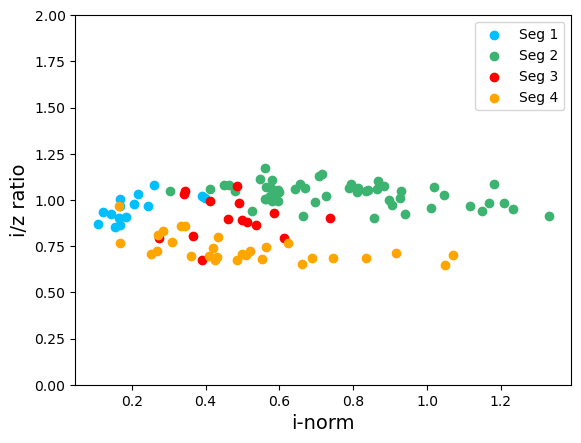

In [25]:
plt.scatter(iparams[0], iparams[0]/zparams[0], label='Seg 1', color='deepskyblue')
plt.scatter(iparams[1], iparams[1]/zparams[1], label='Seg 2', color='mediumseagreen')
plt.scatter(iparams[2], iparams[2]/zparams[2], label='Seg 3', color='red')
plt.scatter(iparams[3], iparams[3]/zparams[3], label='Seg 4', color='orange')

plt.ylim(0,2)
plt.xlabel('i-norm', fontsize=14)
plt.ylabel('i/z ratio', fontsize=14)
plt.legend()

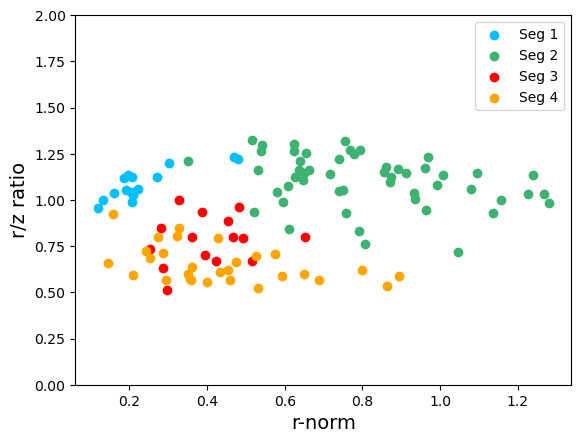

In [26]:
plt.scatter(rparams[0], rparams[0]/zparams[0], label='Seg 1', color='deepskyblue')
plt.scatter(rparams[1], rparams[1]/zparams[1], label='Seg 2', color='mediumseagreen')
plt.scatter(rparams[2], rparams[2]/zparams[2], label='Seg 3', color='red')
plt.scatter(rparams[3], rparams[3]/zparams[3], label='Seg 4', color='orange')

plt.ylim(0,2)
plt.xlabel('r-norm', fontsize=14)
plt.ylabel('r/z ratio', fontsize=14)
plt.legend()
plt.show()

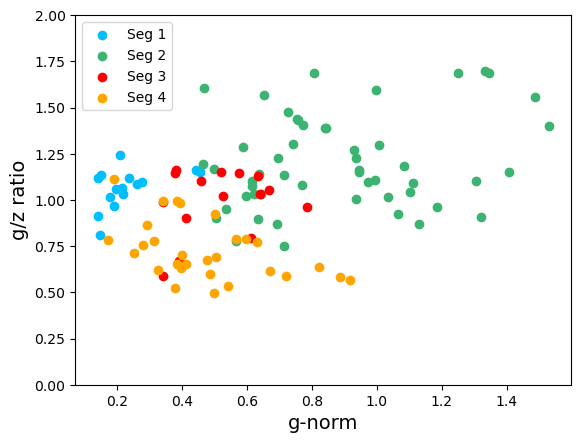

In [27]:
plt.scatter(gparams[0], gparams[0]/zparams[0], label='Seg 1', color='deepskyblue')
plt.scatter(gparams[1], gparams[1]/zparams[1], label='Seg 2', color='mediumseagreen')
plt.scatter(gparams[2], gparams[2]/zparams[2], label='Seg 3', color='red')
plt.scatter(gparams[3], gparams[3]/zparams[3], label='Seg 4', color='orange')

plt.ylim(0,2)
plt.xlabel('g-norm', fontsize=14)
plt.ylabel('g/z ratio', fontsize=14)
plt.legend()
plt.show()